In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model  
warnings.filterwarnings('ignore')

In [2]:
try:
    df = pd.read_excel("boston_housing.xlsx")
    print("dataset loaded successfully")
    display(df.head())
except FileNotFoundError:
  
    print(f"An error occurred: {e}")

dataset loaded successfully


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
if 'df' in locals():
    print("\nDataset shape:", df.shape)
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nData types:")
    print(df.dtypes)
    print("\nSummary statistics:")
    display(df.describe())
    


Dataset shape: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2



Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Summary statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
if 'df' in locals():
    print("missing values per column:")
    print(df.isnull().sum())

missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [46]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

target = 'MEDV'
if target in df.columns: 
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns  
    num_cols_no_target = [col for col in num_cols if col != target]
    for col in num_cols_no_target:
        df = remove_outliers(df, col) 

print("\nDataset shape after outlier removal:", df.shape)


Dataset shape after outlier removal: (138, 15)


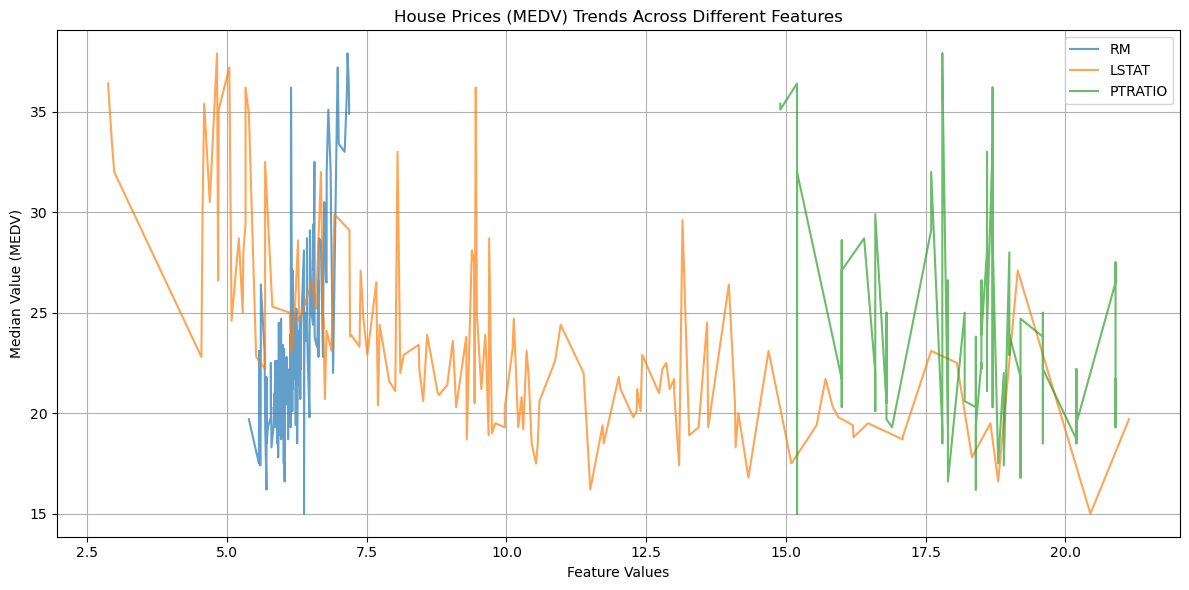

In [52]:
plt.figure(figsize=(12, 6))
line_features = ['RM', 'LSTAT', 'PTRATIO']  # Example features
for feature in line_features:
    sorted_df = df.sort_values(by=feature)
    plt.plot(sorted_df[feature], sorted_df[target], label=feature, alpha=0.7)
plt.title('House Prices (MEDV) Trends Across Different Features')
plt.xlabel('Feature Values')
plt.ylabel('Median Value (MEDV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

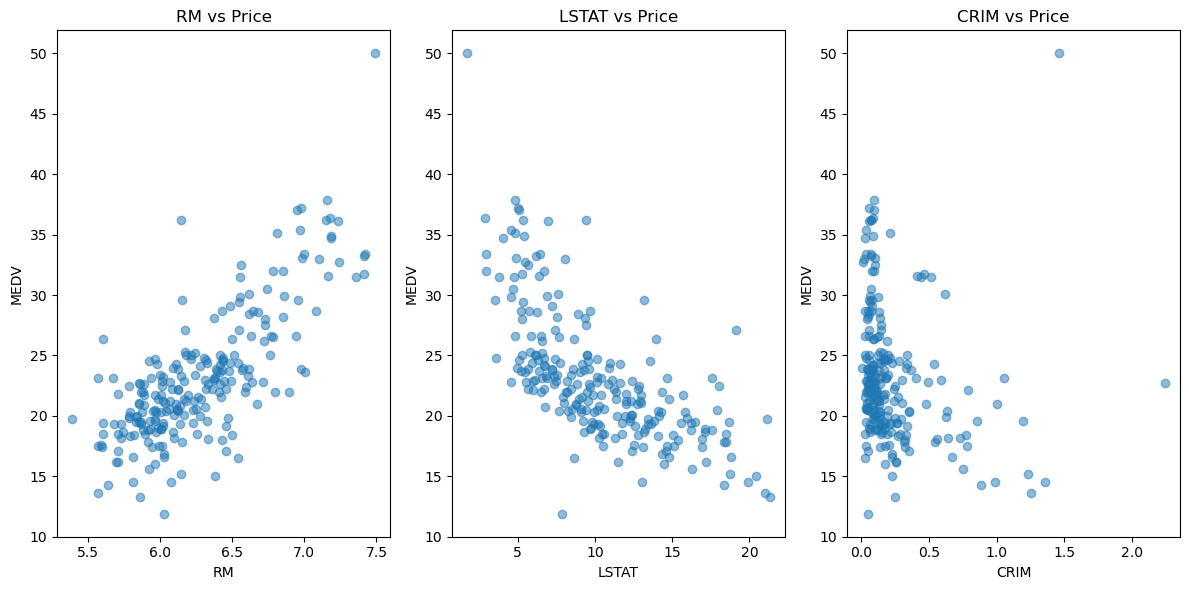

In [14]:
plt.figure(figsize=(12, 6))
scatter_features = ['RM', 'LSTAT', 'CRIM']  # Example features
for i, feature in enumerate(scatter_features, 1):
    plt.subplot(1, len(scatter_features), i)
    plt.scatter(df[feature], df[target], alpha=0.5)
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('MEDV')
plt.tight_layout()
plt.show()

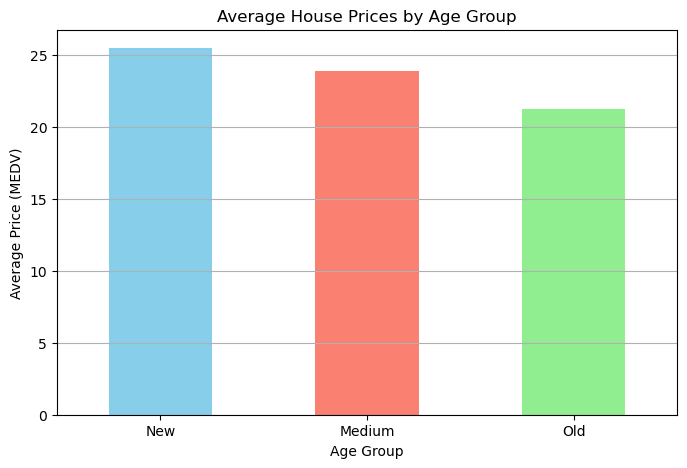

In [16]:
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[0, 35, 70, 100], labels=['New', 'Medium', 'Old'])
plt.figure(figsize=(8, 5))
df.groupby('AGE_GROUP')['MEDV'].mean().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Average House Prices by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Price (MEDV)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

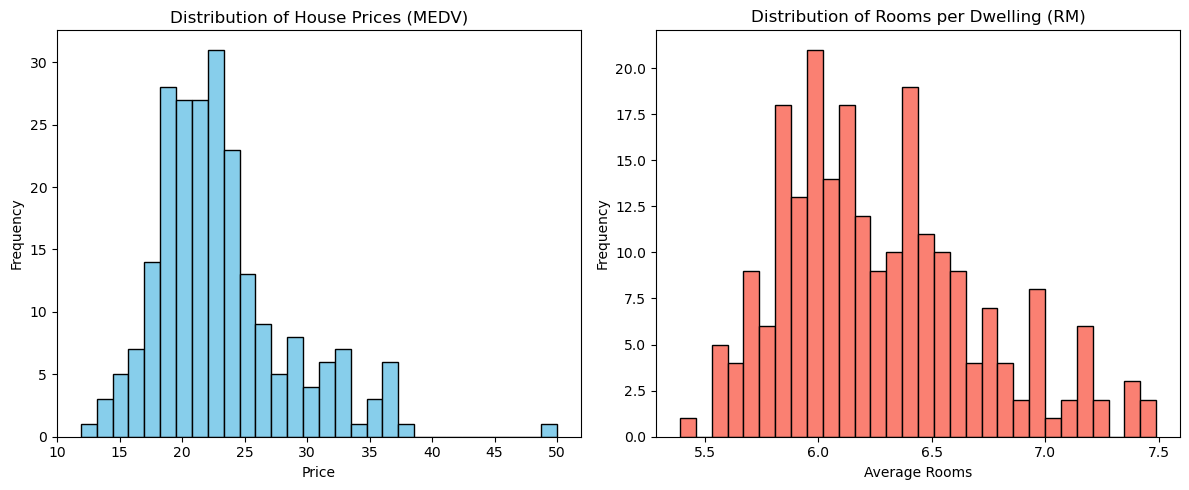

In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['MEDV'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of House Prices (MEDV)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['RM'], bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Rooms per Dwelling (RM)')
plt.xlabel('Average Rooms')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

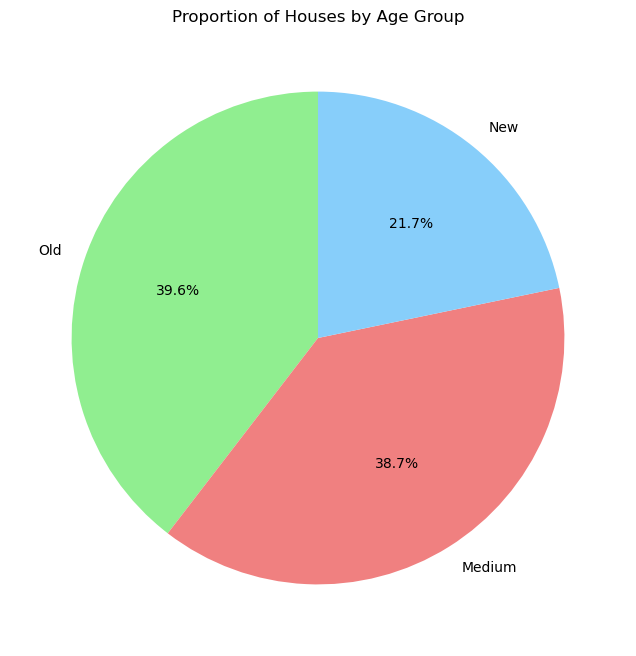

In [20]:
plt.figure(figsize=(8, 8))
age_counts = df['AGE_GROUP'].value_counts()
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
        colors=['lightgreen', 'lightcoral', 'lightskyblue'], startangle=90)
plt.title('Proportion of Houses by Age Group')
plt.show()

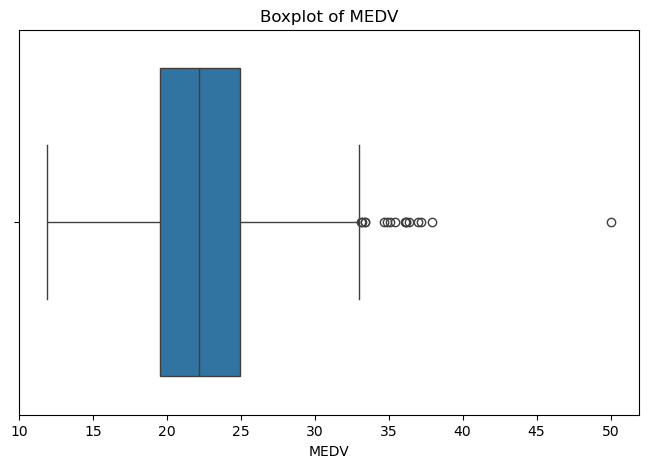

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df[target])
plt.title(f'Boxplot of {target}') 
plt.show()

Top 10 features correlated with MEDV:
RM       0.761955
ZN       0.316941
DIS      0.086164
RAD      0.071076
B       -0.017174
CRIM    -0.172620
TAX     -0.258354
AGE     -0.330875
NOX     -0.340272
INDUS   -0.346462
Name: MEDV, dtype: float64


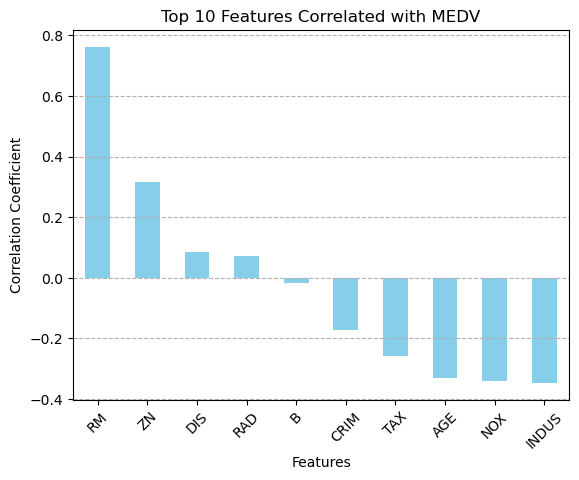

In [24]:
import pandas as pd

# Calculate correlation matrix for NUMERIC COLUMNS ONLY
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # Exclude strings/categories
corr = numeric_df.corr()

# Get top correlations with MEDV (excluding MEDV itself)
target = 'MEDV'
top_corr = corr[target].sort_values(ascending=False).head(11)
print("Top 10 features correlated with MEDV:")
print(top_corr[1:])  # Skip MEDV's self-correlation (1.0)

# Optional: Plot the correlations
top_corr[1:].plot(kind='bar', color='skyblue', title='Top 10 Features Correlated with MEDV')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

In [26]:
if 'df' in locals() and target in df.columns:
    # Prepare data for modeling
    X = df.drop(target, axis=1)
    y = df[target]
    

In [28]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Convert categorical columns to dumSmy variables
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align the columns in both sets (important if test/train differ slightly)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


In [32]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [34]:
# Predict and evaluate
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Results:")
print(f"  MSE: {train_mse:.2f}")
print(f"  R²:  {train_r2:.2f}")

print("\nTest Results:")
print(f"  MSE: {test_mse:.2f}")
print(f"  R²:  {test_r2:.2f}")


Training Results:
  MSE: 7.05
  R²:  0.75

Test Results:
  MSE: 8.48
  R²:  0.74


In [36]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Encode categorical features
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# 2. Align columns (handle missing categories in either set)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)
# 4. Fit a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = model.predict(X_test_scaled)

In [38]:
# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# 7. Show coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': model.coef_
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print("\nTop Coefficients:")
print(coef_df)

Mean Squared Error: 8.48
R-squared: 0.74

Top Coefficients:
             Feature   Coefficient
5                 RM  3.585939e+00
13     AGE_GROUP_New  6.266304e-01
8                RAD  5.990611e-01
0               CRIM  4.834793e-01
14  AGE_GROUP_Medium  2.179055e-01
3               CHAS -3.330669e-16
4                NOX -6.162774e-03
11                 B -3.697466e-02
1                 ZN -4.207364e-02
2              INDUS -1.588666e-01
12             LSTAT -1.628967e-01
6                AGE -3.727583e-01
15     AGE_GROUP_Old -7.566967e-01
9                TAX -8.397617e-01
7                DIS -1.296973e+00
10           PTRATIO -1.419141e+00


In [40]:
# 8. Show intercept
print(f"\nModel Intercept: {model.intercept_:.2f}")

# 9. Predict a single new example
sample = X.iloc[[0]]  # Original unencoded sample
sample_encoded = pd.get_dummies(sample)
sample_encoded = sample_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
sample_scaled = scaler.transform(sample_encoded)

predicted_price = model.predict(sample_scaled)[0]
actual_price = y.iloc[0]

print(f"\nSample Prediction:")
print(f"  Actual Price: ${actual_price * 1000:.0f}")
print(f"  Predicted Price: ${predicted_price * 1000:.0f}")



Model Intercept: 23.18

Sample Prediction:
  Actual Price: $24000
  Predicted Price: $27830


In [42]:
from sklearn.metrics import r2_score

# Calculate simple regression "accuracy"
accuracy = r2_score(y_test, y_pred)
print(f"Accuracy (R² Score): {accuracy:.2f}")


Accuracy (R² Score): 0.74
